# 06 -- Design Catalog

Explore the trade-off space between aerodynamic performance and manufacturability:

1. **Build catalog** — baseline, v2 optimized, and alpha-blended designs
2. **Aero evaluation** — 10-target surrogate (with CG correction + control derivatives)
3. **Manufacturability scoring** — curvature, thickness, mold complexity
4. **Pareto analysis** — L/D vs. manufacturability trade-off front
5. **Geometric comparison** — planform overlays, radar charts
6. **STEP export** — batch export for downstream structural/manufacturing pipeline

In [1]:
import sys
sys.path.insert(0, '..')

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from src.config import load_all
from src.optimization.catalog import DesignCatalog
from src.evaluation.manufacturability import compute_manufacturability
from src.visualization.comparison import (
    plot_pareto, plot_radar, plot_planform_overlay, plot_summary_table,
)

from src.visualization.style import apply_style, COLORS
apply_style()

cfg = load_all()
mission = cfg['mission']
feasibility = cfg['feasibility']

## 1. Build the Design Catalog

Two reference points + 4 interpolated designs spanning the full trade-off spectrum.

In [2]:
catalog = DesignCatalog()

# ── Reference designs ──
catalog.add_baseline()

# Load v2 optimized design
try:
    catalog.add_optimized('../output/best_x_v2.npy')
    print('Using v2 optimized design')
except FileNotFoundError:
    catalog.add_optimized('../output/best_x.npy')
    print('Using v1 design (fallback)')

# ── Top feasible designs from the LHS dataset ──
from src.optimization.database import EvaluationDatabase

db = EvaluationDatabase.load('../data/eval_database.json')
X_arr, results = db.to_arrays()

# Find top 5 feasible designs by L/D (diverse)
feasible_idx = [i for i, r in enumerate(results) 
                if r.get('is_feasible', False) and r.get('L_over_D', 0) > 0]
feasible_idx.sort(key=lambda i: -results[i]['L_over_D'])

# Add top 5 with diversity filter (min distance between designs)
from src.parameterization.design_variables import get_bounds_arrays
lb, ub = get_bounds_arrays()
diag = np.linalg.norm(ub - lb)
selected = []
for idx in feasible_idx:
    x = X_arr[idx]
    # Skip if too close to an already selected design
    if any(np.linalg.norm(x - s) / diag < 0.05 for s in selected):
        continue
    selected.append(x)
    name = f'lhs_top{len(selected)}'
    catalog.add(name, x, origin='dataset', tags=['lhs'])
    if len(selected) >= 5:
        break

print(f'Added {len(selected)} top feasible designs from LHS dataset')

# ── Alpha-blends between best LHS and optimized ──
if len(selected) > 0:
    best_lhs = f'lhs_top1'
    catalog.interpolate(best_lhs, 'optimized', [0.33, 0.67])

print(f'\nCatalog: {len(catalog)} designs')
for e in catalog:
    p = e.params
    print(f'  {e.name:20s}  span={2*p.half_span:.2f}m  t/c={p.body_tc_root:.3f}  '
          f'taper={p.taper_ratio:.3f}  sweep={p.le_sweep_deg:.1f}')

Using v2 optimized design
Added 5 top feasible designs from LHS dataset

Catalog: 9 designs
  baseline              span=1.50m  t/c=0.180  taper=0.150  sweep=26.0
  optimized             span=1.28m  t/c=0.198  taper=0.208  sweep=31.1
  lhs_top1              span=1.54m  t/c=0.205  taper=0.292  sweep=18.9
  lhs_top2              span=1.96m  t/c=0.249  taper=0.123  sweep=23.5
  lhs_top3              span=1.63m  t/c=0.187  taper=0.199  sweep=27.7
  lhs_top4              span=1.15m  t/c=0.163  taper=0.123  sweep=28.3
  lhs_top5              span=1.52m  t/c=0.158  taper=0.313  sweep=26.1
  blend_33              span=1.45m  t/c=0.203  taper=0.264  sweep=22.9
  blend_67              span=1.36m  t/c=0.201  taper=0.236  sweep=27.1


## 2. Aerodynamic Evaluation (Surrogate)

Instant evaluation via the pre-trained MLP ensemble (7 VLM primitives → full reconstruction).

In [3]:
catalog.evaluate_aero(
    mission=mission,
    feasibility=feasibility,
    use_surrogate=False,  # AVL validation — surrogat has 30% L/D gap
)

  baseline              L/D=-14.21  X
  optimized             L/D= 13.05  OK
  lhs_top1              L/D= 18.76  X
  lhs_top2              L/D= 15.01  OK
  lhs_top3              L/D= 14.26  OK
  lhs_top4              L/D= 11.63  X
  lhs_top5              L/D= 12.26  OK
  blend_33              L/D= 16.44  OK
  blend_67              L/D= 14.51  OK


## 3. Manufacturability Scoring

Geometric metrics quantifying fabrication difficulty: twist/dihedral gradients, minimum thickness, mold complexity, taper severity.

In [4]:
catalog.evaluate_manufacturability()

# Detailed breakdown for baseline vs optimized
for name in ['baseline', 'optimized']:
    e = catalog[name]
    mm = e.manufacturing_metrics
    print(f'\n=== {name.upper()} (score={mm["manufacturability_score"]:.3f}) ===')
    for k, v in mm.items():
        if k.startswith('sub_'):
            print(f'  {k[4:]:25s}  {v:.3f}')
    print(f'  {"twist_gradient_max":25s}  {mm["twist_gradient_max"]:.1f} °/m')
    print(f'  {"dihedral_gradient_max":25s}  {mm["dihedral_gradient_max"]:.1f} °/m')
    print(f'  {"thickness_tip_mm":25s}  {mm["thickness_tip_mm"]:.1f} mm')
    print(f'  {"n_dihedral_breaks":25s}  {mm["n_dihedral_breaks"]}')

  baseline              manuf=0.631
  optimized             manuf=0.409
  lhs_top1              manuf=0.422
  lhs_top2              manuf=0.259
  lhs_top3              manuf=0.264
  lhs_top4              manuf=0.299
  lhs_top5              manuf=0.431
  blend_33              manuf=0.409
  blend_67              manuf=0.454

=== BASELINE (score=0.631) ===
  twist_smoothness           0.593
  dihedral_smoothness        0.159
  dihedral_simplicity        0.667
  tip_robustness             0.912
  taper_simplicity           0.412
  blend_smoothness           0.857
  sweep_continuity           0.778
  twist_simplicity           0.900
  equipment_space            0.169
  mold_size                  1.000
  twist_gradient_max         11.1 °/m
  dihedral_gradient_max      88.9 °/m
  thickness_tip_mm           7.6 mm
  n_dihedral_breaks          1

=== OPTIMIZED (score=0.409) ===
  twist_smoothness           0.000
  dihedral_smoothness        0.000
  dihedral_simplicity        1.000
  tip_robustn

## 4. Summary Table

In [5]:
from src.geometry.control_surfaces import compute_control_surface_geometry

print(catalog.summary())
print()

# Pandas DataFrame for detailed comparison
df = catalog.to_dataframe()

# Add control surface dimension columns
elevon_spans = []
aileron_spans = []
for e in catalog:
    cs_list = compute_control_surface_geometry(e.params)
    ev_span = 0.0
    ai_span = 0.0
    for cs in cs_list:
        if 'elevon' in cs.name.lower():
            ev_span = cs.span * 100  # m -> cm
        elif 'aileron' in cs.name.lower():
            ai_span = cs.span * 100  # m -> cm
    elevon_spans.append(ev_span)
    aileron_spans.append(ai_span)

df['elevon_span_cm'] = elevon_spans
df['aileron_span_cm'] = aileron_spans

cols = ['origin', 'L_over_D', 'static_margin', 'is_feasible',
        'manuf_manufacturability_score', 'struct_mass', 'endurance_min',
        'half_span', 'body_tc_root', 'taper_ratio',
        'elevon_deflection', 'Cl_beta', 'x_cg_frac',
        'elevon_span_cm', 'aileron_span_cm']
display(df[[c for c in cols if c in df.columns]].round(3))

DesignCatalog: 9 designs

Name                 Origin            L/D  Feas  Manuf Tags
------------------------------------------------------------
baseline             default        -14.21     X  0.631 baseline, reference
optimized            optimization    13.05    OK  0.409 optimized, reference, feasible
lhs_top1             dataset         18.76     X  0.422 lhs
lhs_top2             dataset         15.01    OK  0.259 lhs, feasible
lhs_top3             dataset         14.26    OK  0.264 lhs, feasible
lhs_top4             dataset         11.63     X  0.299 lhs
lhs_top5             dataset         12.26    OK  0.431 lhs, feasible
blend_33             interpolation   16.44    OK  0.409 blend, alpha=0.33, feasible
blend_67             interpolation   14.51    OK  0.454 blend, alpha=0.67, feasible



,origin,L_over_D,static_margin,is_feasible,manuf_manufacturability_score,struct_mass,endurance_min,half_span,body_tc_root,taper_ratio,elevon_deflection,Cl_beta,x_cg_frac,elevon_span_cm,aileron_span_cm
name,,,,,,,,,,,,,,,
baseline,default,-14.211,-0.025,False,0.631,0.708,5.983,0.750,0.180,0.150,-23.459,-0.039,0.436,35.036,24.533
optimized,optimization,13.049,0.150,True,0.409,0.430,8.551,0.638,0.198,0.208,-1.482,-0.051,0.447,30.787,21.551
lhs_top1,dataset,18.763,-0.039,False,0.422,0.552,7.950,0.769,0.205,0.292,4.275,-0.046,0.436,36.097,25.287
lhs_top2,dataset,15.006,0.110,True,0.259,0.851,6.226,0.979,0.249,0.123,2.964,-0.062,0.528,47.047,32.948
lhs_top3,dataset,14.256,0.072,True,0.264,0.547,7.044,0.813,0.187,0.199,2.402,-0.031,0.450,37.809,26.477
lhs_top4,dataset,11.628,-0.051,False,0.299,0.540,6.117,0.573,0.163,0.123,2.355,-0.028,0.424,24.789,17.352
lhs_top5,dataset,12.261,-0.023,True,0.431,0.758,6.759,0.761,0.158,0.313,0.770,-0.066,0.446,35.853,25.098
blend_33,interpolation,16.445,0.014,True,0.409,0.508,8.356,0.726,0.203,0.264,2.063,-0.051,0.441,34.296,24.015
blend_67,interpolation,14.508,0.078,True,0.454,0.467,8.542,0.682,0.201,0.236,0.170,-0.053,0.444,32.499,22.751


## 5. Pareto Plot — L/D vs. Manufacturability

The fundamental trade-off: aerodynamic performance vs. fabrication ease. The Pareto front shows the best achievable compromise at each performance level.

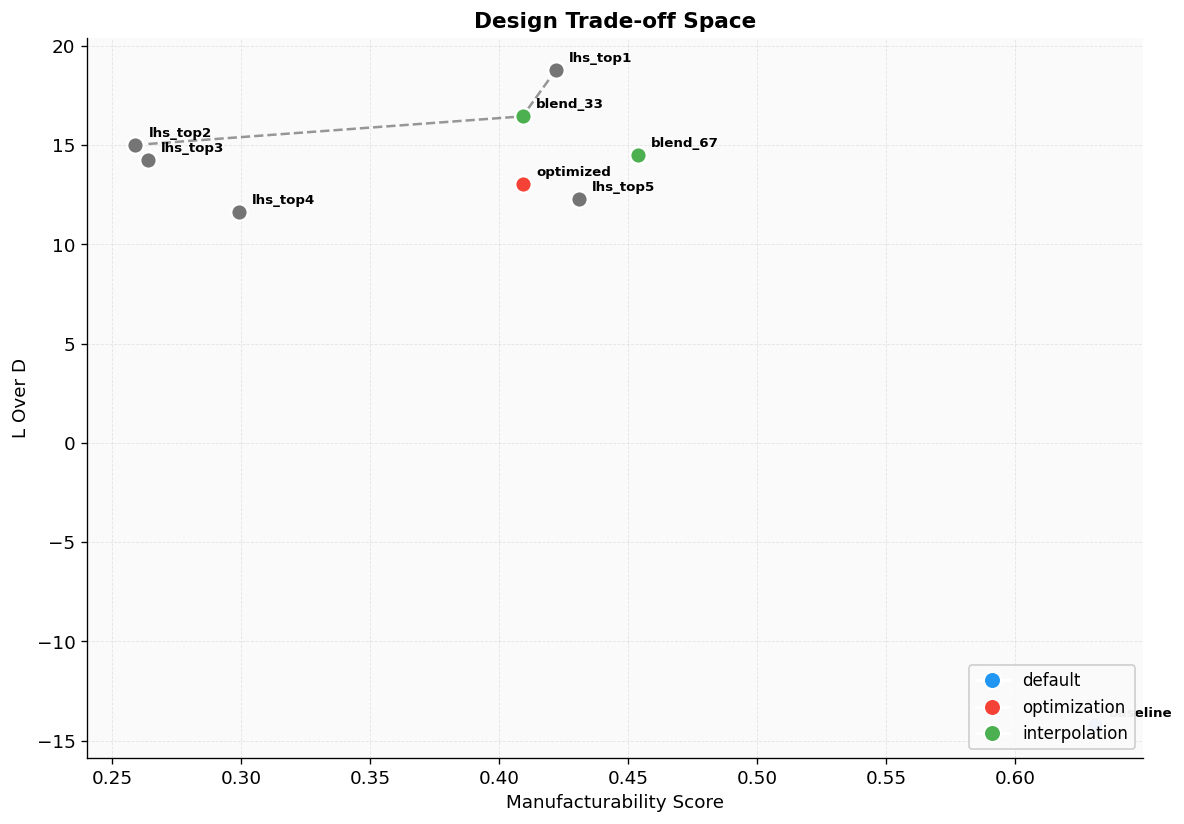

In [6]:
fig = plot_pareto(catalog, save_path='../output/catalog_pareto.png')

## 6. Radar Chart — Multi-Criteria Comparison

Normalized comparison across 6 dimensions: L/D, stability, manufacturability, volume, endurance, and structural mass.

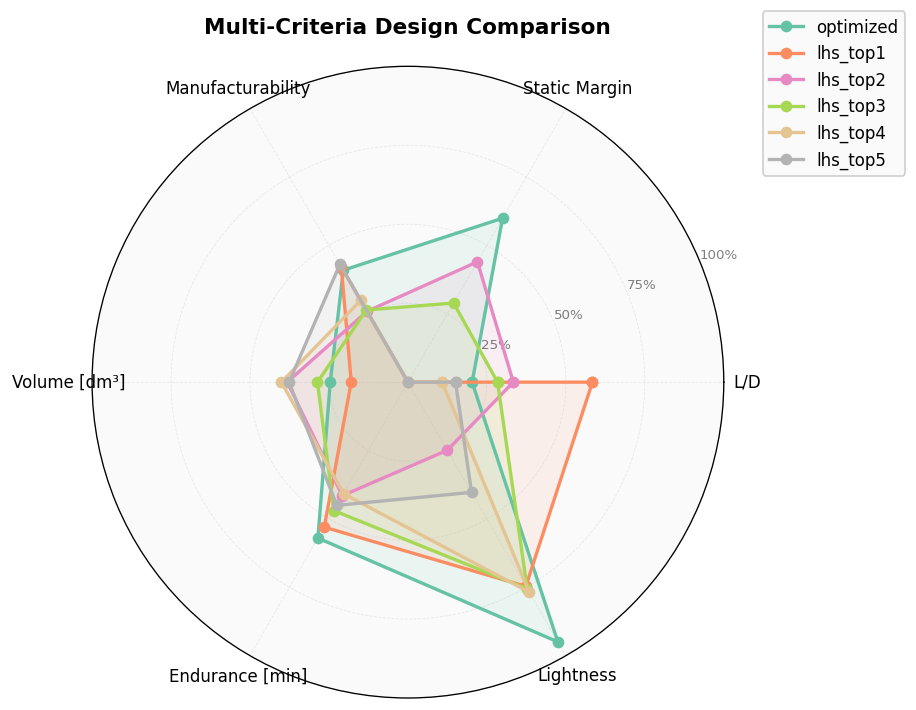

In [7]:
# Compare key designs: baseline, top LHS designs, blends, and optimized
radar_designs = [n for n in catalog.names if n != 'baseline'][:6]  # skip infeasible baseline
fig = plot_radar(catalog, designs=radar_designs,
                 save_path='../output/catalog_radar.png')
plt.show()

## 7. Geometric Comparison — Planform Overlays

Top view (planform) and front view (dihedral) superimposed for all catalog designs.

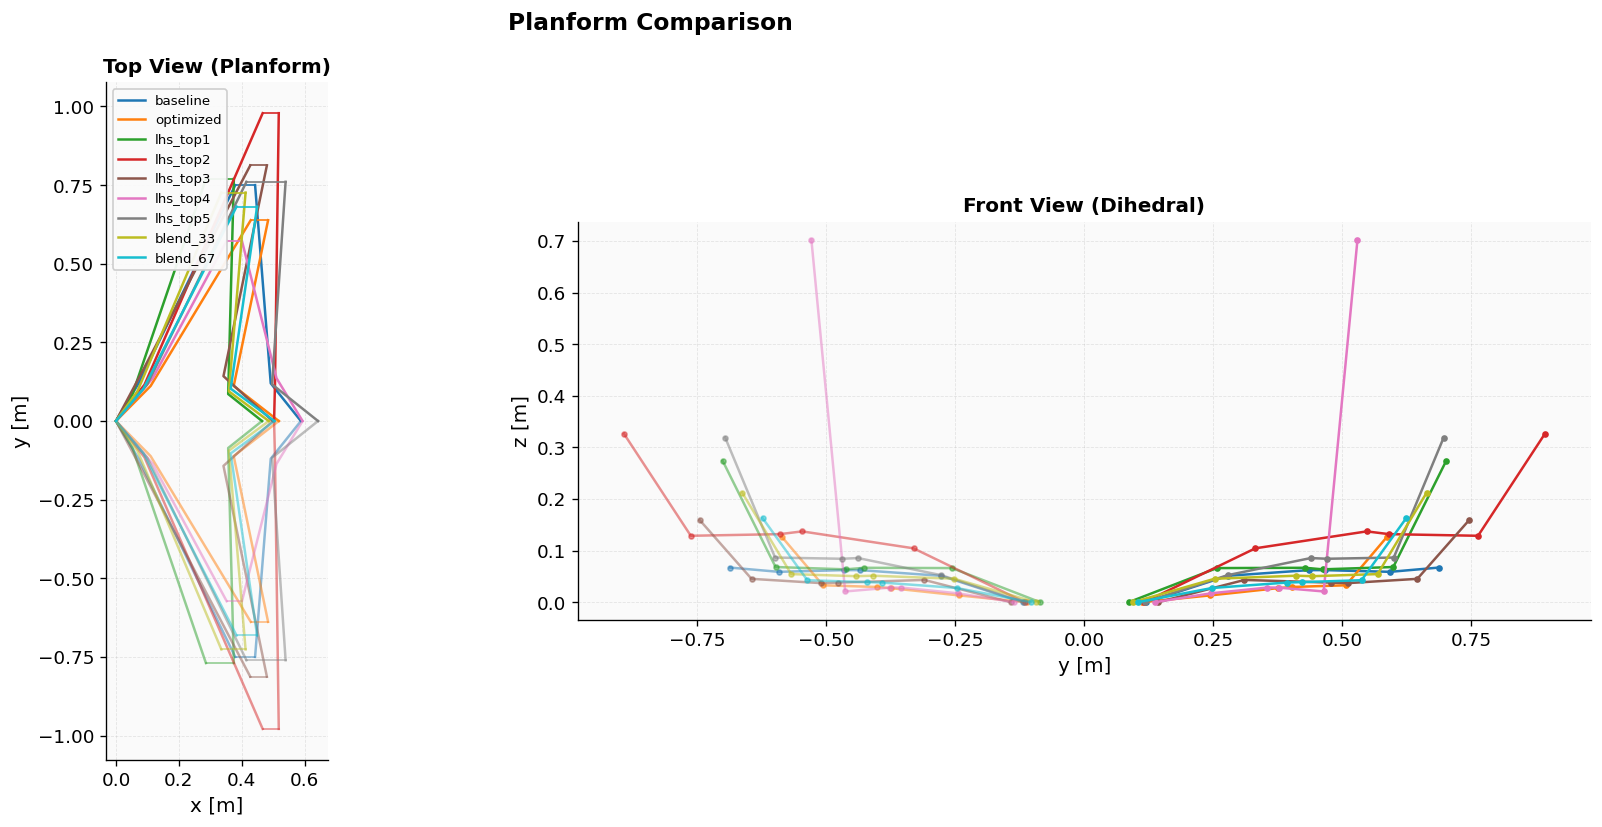

In [8]:
fig = plot_planform_overlay(catalog, save_path='../output/catalog_planforms.png')
plt.show()

## 8. Summary Table (visual)

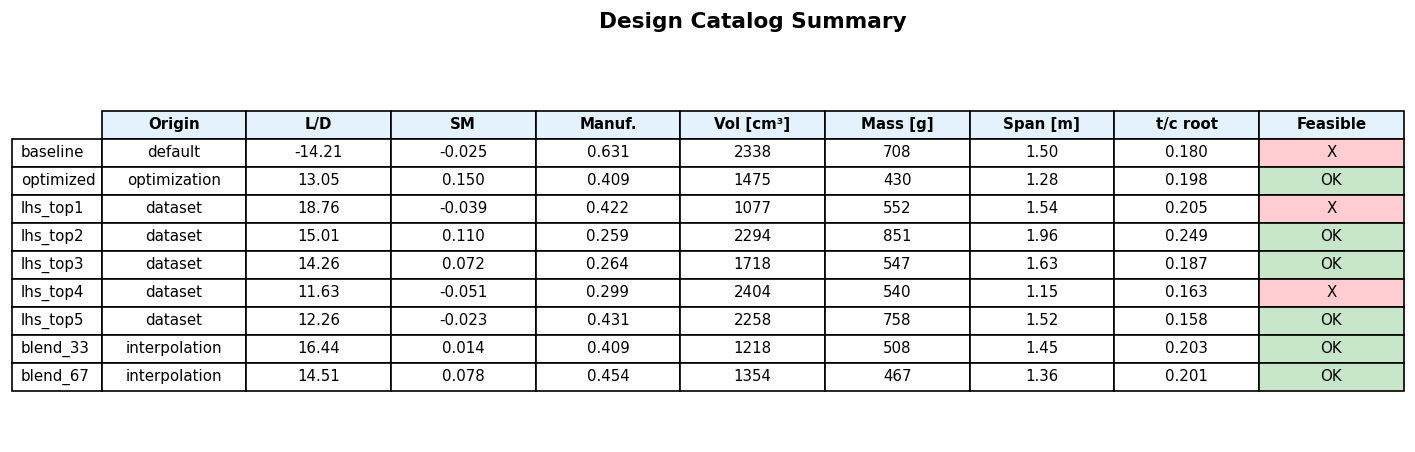

In [9]:
fig = plot_summary_table(catalog, save_path='../output/catalog_table.png')
plt.show()

## 9. Batch STEP Export

Export selected designs as STEP v2 (OML solid) for downstream structural analysis.
Each file is a watertight NURBS solid ready for FEA meshing.

In [10]:
# Select which designs to export (uncomment to run — takes ~30s per design)
# paths = catalog.export_all_step(
#     output_dir='../output/catalog',
#     version='v2',
#     n_profile=100,
# )
# for name, path in paths.items():
#     print(f'  {name}: {path}')

## 10. Save Catalog

Persist the catalog (designs + metrics) as JSON for use by external pipelines (FEA, CFD, manufacturing).

In [11]:
catalog.save('../output/catalog.json')
print(f'Catalog saved: {len(catalog)} designs → output/catalog.json')

# To reload in another session:
# catalog = DesignCatalog.load('../output/catalog.json')

Catalog saved: 9 designs → output/catalog.json
